In [1]:
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib widget
import seaborn as sns
sns.set_style("whitegrid")

from cone import CircularCone3D
from evaluation import check

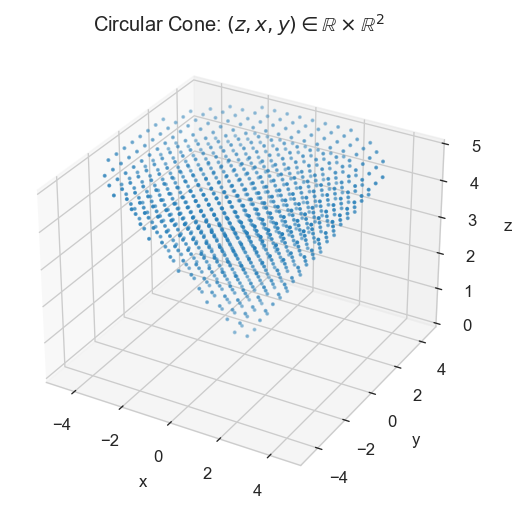

In [2]:
bdd = 5
num = 20
theta = np.pi/4

cone = CircularCone3D(boundary=bdd, number=num, theta=theta, verbose=True)
x,y,z = cone.x, cone.y, cone.z # x_1=z in R and x_2=[x,y] in R^2
n = x.shape[0] # number of points in cone

In [3]:
breaker = False
point_idx = []
for i in range(n):
    for j in range(i, n):
        vec_1 = np.array([z[i], x[i], y[i]])
        vec_2 = np.array([z[j], x[j], y[j]])

        if check(vec_1, vec_2, theta).bool:
            pass
        else:
            print("found case not in SOC")
            print(i,j)
            point_idx.append([i,j])
    #         breaker = True
    #         break
    # if breaker:
    #     break

found case not in SOC
253 719
found case not in SOC
254 720
found case not in SOC
255 721
found case not in SOC
287 685
found case not in SOC
288 686
found case not in SOC
289 687


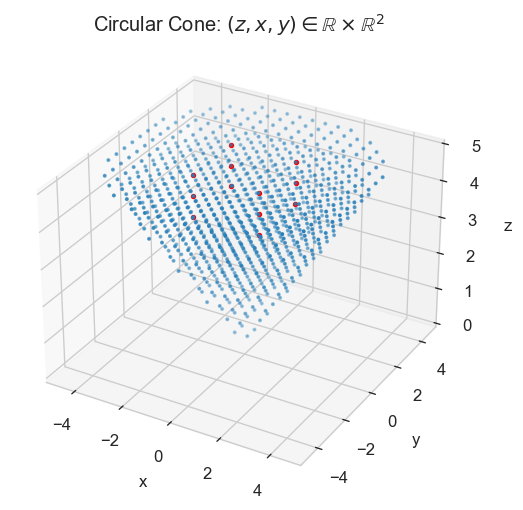

In [4]:
points = []
for idx in point_idx:
    points.append([x[idx[0]], y[idx[0]], z[idx[0]]])
    points.append([x[idx[1]], y[idx[1]], z[idx[1]]])

cone.plotCone(points)

In [5]:
# Ex

i = 253
j = 719

p1 = np.array([z[i], x[i], y[i]])
p2 = np.array([z[j], x[j], y[j]])

print("point 1:", p1)
print("point 2:", p2)

print("-"*60)
if p1[0] >= np.linalg.norm(p1[1:])*(1/np.tan(theta)):
    print("point 1 is in circular cone with theta {} deg".format(np.round(theta*(180/np.pi)),2))
if p2[0] >= np.linalg.norm(p2[1:])*(1/np.tan(theta)):
    print("point 2 is in circular cone with theta {} deg".format(np.round(theta*(180/np.pi)),2))

def inv(vec):
    norm = np.linalg.norm(vec[1:])
    lambda_1_inv = 1/(vec[0] - norm*(1/np.tan(theta)))
    lambda_2_inv = 1/(vec[0] + norm*np.tan(theta))
    x_1 = lambda_1_inv*np.sin(theta)**2+lambda_2_inv*np.cos(theta)**2
    if norm == 0:
        x_2 = np.zeros(len(vec[1:]))
        x_2[0] = 1
    else:
        x_2 = (lambda_2_inv-lambda_1_inv)*(np.sin(theta)*np.cos(theta))*(vec[1:]/norm)
    return np.insert(x_2, 0, x_1, axis=0)

print("-"*60)
A = (p1 + p2)/2
H = inv((inv(p1)+ inv(p2))/2)
vector2check = A - H

if vector2check[0] >= np.linalg.norm(vector2check[1:]):
    print("A - H is in SOC")
else:
    print("A - H is not in SOC")
    print("x1=", vector2check[0])
    print("||x2||=", np.linalg.norm(vector2check[1:]))
    print("x1 < ||x2||")

point 1: [ 3.88888889 -1.31578947 -1.31578947]
point 2: [3.88888889 1.31578947 1.31578947]
------------------------------------------------------------
point 1 is in circular cone with theta 45.0 deg
point 2 is in circular cone with theta 45.0 deg
------------------------------------------------------------
A - H is not in SOC
x1= 0.8903838543727742
||x2||= 1.0
x1 < ||x2||
